## COMPAS - 2 OBJECTIVES

### Multi Layer Perceptron

* **Dataset:** Compass
* **Task:** Classification
* **Target:** Two year recidivism
* **Objectives:** Non-white and White individuals

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd

from sklearn.metrics import log_loss
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim

In [3]:
from machinemoo import moo
from machinemoo import get_objectives, get_models
from machinemoo.analysis.visualization import plot_pareto, plot_multiple_hypervolumes
from machinemoo.analysis.metrics import compute_hypervolume_progress

from scalarization import MLPScalarization

Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10


### Dataset and Model

In [4]:
# Setting a seed for reproducibility
seed = 42

In [5]:
import random
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [6]:
data = pd.read_csv("dataset/compas_onerace.csv")
data = data.drop("Unnamed: 0", axis=1)

fair_feature = "not_white"
pred_feature = "Two_yr_Recidivism"

categories_fair_class = []

for index, row in data.iterrows():
    if row[pred_feature] == -1:
        categories_fair_class.append(row[fair_feature])
    else:
        categories_fair_class.append(row[fair_feature]+2)

X = data.drop([pred_feature], axis=1)
# y = data[pred_feature]
y = (data[pred_feature] + 1)//2

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size = int(data.shape[0]*0.5),
                                                    stratify = categories_fair_class,
                                                    random_state = seed)

## MOO Modeling and Training

* MOO methods:
    * MOLA
    * MONISE
    * Random Weights

In [7]:
# Setting optimization parameter to use in all methods in this experiment
opt_params = {
    'node_time_limit': 2,
    'target_size': 150,
    'target_gap': 0,
    'node_gap': 0.05,
    'norm': False
}
num_objs = 2
results = {}

In [8]:
# Logistic Regression with equal weight to use as baseline model
equal = MLPScalarization(num_objs=2,
                        X=X_train, 
                        y=y_train, 
                        fair_feat=fair_feature,
                        #tol=tol, max_iter=max_iter
                        )
equal.optimize(np.array([0.5, 0.5]))

## MOLA

15:07:55 | DEBUG | machinemoo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 150, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}
15:07:55 | DEBUG | machinemoo | Finding 1th individual minimum
15:08:07 | DEBUG | machinemoo | Finding 2th individual minimum
15:08:20 | DEBUG | machinemoo | Calculated weights: [0.46270785 0.53729215]
15:08:20 | DEBUG | machinemoo | Importance: 0.014506569436435551
15:08:20 | DEBUG | machinemoo | Global lower bound (y*): [0.59233915 0.59624231]
15:08:20 | DEBUG | machinemoo | Iteration 1
15:08:20 | DEBUG | machinemoo | Solutions list: [array([0.59233915, 0.62324172]), array([0.62369062, 0.59624231])]


new solution added [0.59156558 0.5972906 ]
solution dominated [0.59233915 0.62324172]


15:08:24 | DEBUG | machinemoo | Calculated weights: [0.03160128 0.96839872]
15:08:24 | DEBUG | machinemoo | Importance: 0.0010151585672361378
15:08:24 | DEBUG | machinemoo | Global lower bound (y*): [0.59156558 0.59624231]
15:08:24 | DEBUG | machinemoo | Iteration 2
15:08:24 | DEBUG | machinemoo | Solutions list: [array([0.59156558, 0.5972906 ]), array([0.62369062, 0.59624231])]


new solution added [0.59817013 0.59424532]
solution dominated [0.62369062 0.59624231]


15:08:36 | DEBUG | machinemoo | Calculated weights: [0.31557862 0.68442138]
15:08:36 | DEBUG | machinemoo | Importance: 0.002084279677589382
15:08:36 | DEBUG | machinemoo | Global lower bound (y*): [0.59156558 0.59424532]
15:08:36 | DEBUG | machinemoo | Iteration 3
15:08:36 | DEBUG | machinemoo | Solutions list: [array([0.59817013, 0.59424532]), array([0.59156558, 0.5972906 ])]


...

15:09:45 | DEBUG | machinemoo | Calculated weights: [0.37350979 0.62649021]
15:09:45 | DEBUG | machinemoo | Importance: 0.00011220895498131878
15:09:45 | DEBUG | machinemoo | Global lower bound (y*): [0.57009526 0.5829906 ]
15:09:45 | DEBUG | machinemoo | Iteration 148
15:09:45 | DEBUG | machinemoo | Solutions list: [array([0.57009526, 0.58324518]), array([0.57038901, 0.58307005]), array([0.57067276, 0.58299991]), array([0.570959 , 0.5829906])]


new solution added [0.57025853 0.58307764]


15:09:45 | DEBUG | machinemoo | Calculated weights: [0.50644862 0.49355138]
15:09:45 | DEBUG | machinemoo | Importance: 8.48394747963166e-05
15:09:45 | DEBUG | machinemoo | Global lower bound (y*): [0.57009526 0.5829906 ]
15:09:45 | DEBUG | machinemoo | Iteration 149
15:09:45 | DEBUG | machinemoo | Solutions list: [array([0.57025853, 0.58307764]), array([0.57009526, 0.58324518]), array([0.57038901, 0.58307005]), array([0.57067276, 0.58299991]), array([0.570959 , 0.5829906])]


new solution added [0.56991706 0.58326349]


15:09:45 | DEBUG | machinemoo | Calculated weights: [0.35243901 0.64756099]
15:09:45 | DEBUG | machinemoo | Importance: 6.350369581886728e-05
15:09:45 | DEBUG | machinemoo | Global lower bound (y*): [0.56991706 0.5829906 ]
15:09:45 | DEBUG | machinemoo | Iteration 150
15:09:45 | DEBUG | machinemoo | Solutions list: [array([0.56991706, 0.58326349]), array([0.57025853, 0.58307764]), array([0.57009526, 0.58324518]), array([0.57038901, 0.58307005]), array([0.57067276, 0.58299991]), array([0.570959 , 0.5829906])]


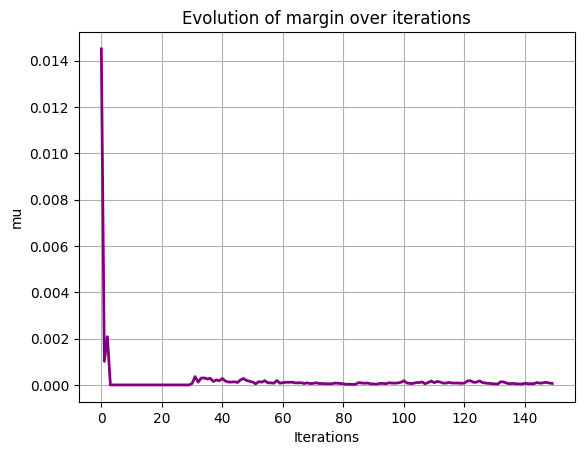

15:09:45 | INFO | machinemoo | Fit runtime: 110.75 seconds


In [9]:
method = 'mola'
w_scalar = MLPScalarization(num_objs=2, 
                            X=X_train, 
                            y=y_train,
                            fair_feat=fair_feature,
                            gradient=False)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = moopt.get_hypervolumes()
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

In [10]:
objs_all = np.array([s.objs for s in moopt.history_list])

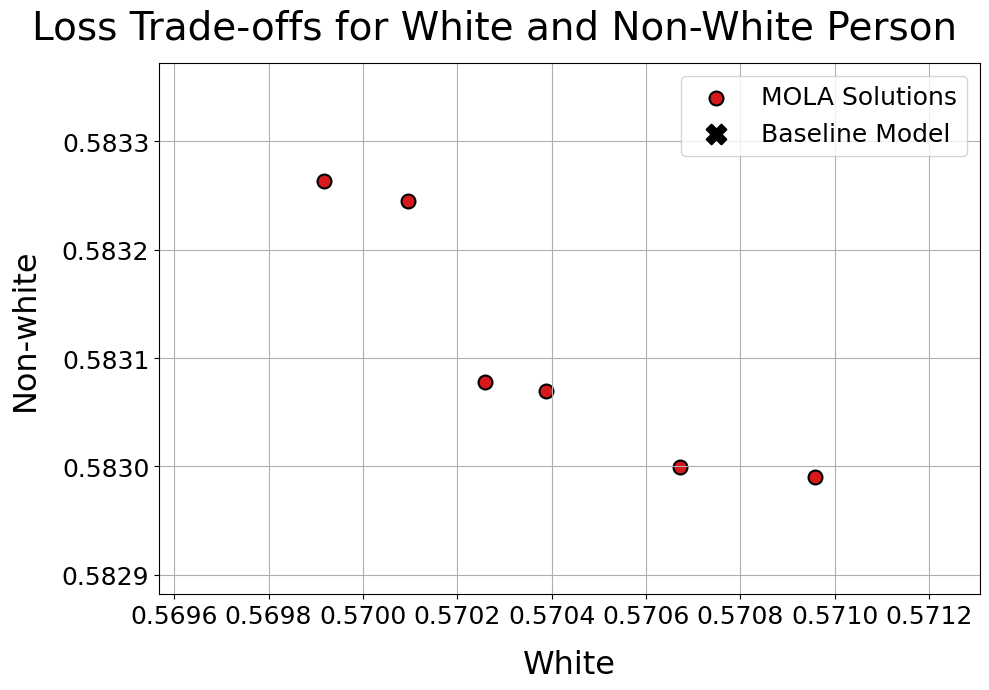

In [11]:
title="Loss Trade-offs for White and Non-White Person"
plot_pareto(methods={'mola': objs},
            labels=("White", "Non-White"), 
            title=title,
            point=equal.objs,
            fontsize=23,
            figsize=(10,7),
            save_path='images/2_objs_mola_mlp.pdf'
            )

15:09:46 | DEBUG | machinemoo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 150, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}
15:09:46 | DEBUG | machinemoo | Finding 1th individual minimum
15:09:46 | DEBUG | machinemoo | Finding 2th individual minimum
15:09:47 | DEBUG | machinemoo | Calculated weights: [0.53241012 0.46758988]
15:09:47 | DEBUG | machinemoo | Importance: 0.012535855457952938
15:09:47 | DEBUG | machinemoo | Global lower bound (y*): [0.5918786  0.59776132]
15:09:47 | DEBUG | machinemoo | Iteration 1
15:09:47 | DEBUG | machinemoo | Solutions list: [array([0.5918786 , 0.62457084]), array([0.6154241 , 0.59776132])]


new solution added [0.59132615 0.59963829]
solution dominated [0.5918786  0.62457084]


15:09:47 | DEBUG | machinemoo | Calculated weights: [0.07226174 0.92773826]
15:09:47 | DEBUG | machinemoo | Importance: 0.0017421780918570676
15:09:47 | DEBUG | machinemoo | Global lower bound (y*): [0.59132615 0.59776132]
15:09:47 | DEBUG | machinemoo | Iteration 2
15:09:47 | DEBUG | machinemoo | Solutions list: [array([0.59132615, 0.59963829]), array([0.6154241 , 0.59776132])]


new solution added [0.59341871 0.59705778]
solution dominated [0.6154241  0.59776132]


15:09:47 | DEBUG | machinemoo | Calculated weights: [0.55220802 0.44779198]
15:09:47 | DEBUG | machinemoo | Importance: 0.0011555270867387168
15:09:47 | DEBUG | machinemoo | Global lower bound (y*): [0.59132615 0.59705778]
15:09:47 | DEBUG | machinemoo | Iteration 3
15:09:47 | DEBUG | machinemoo | Solutions list: [array([0.59341871, 0.59705778]), array([0.59132615, 0.59963829])]


...

15:10:37 | DEBUG | machinemoo | Calculated weights: [0.47170862 0.52829138]
15:10:37 | DEBUG | machinemoo | Importance: 5.322863814782863e-05
15:10:37 | DEBUG | machinemoo | Global lower bound (y*): [0.56644169 0.58320499]
15:10:37 | DEBUG | machinemoo | Iteration 148
15:10:37 | DEBUG | machinemoo | Solutions list: [array([0.56666512, 0.58320499]), array([0.5665581 , 0.58330054]), array([0.56645108, 0.58351135]), array([0.56652242, 0.58346183]), array([0.56644169, 0.58368611])]


new solution added [0.56658757 0.58324564]


15:10:37 | DEBUG | machinemoo | Calculated weights: [0.34396257 0.65603743]
15:10:37 | DEBUG | machinemoo | Importance: 2.9182642174552242e-05
15:10:37 | DEBUG | machinemoo | Global lower bound (y*): [0.56644169 0.58320499]
15:10:37 | DEBUG | machinemoo | Iteration 149
15:10:37 | DEBUG | machinemoo | Solutions list: [array([0.56658757, 0.58324564]), array([0.56666512, 0.58320499]), array([0.5665581 , 0.58330054]), array([0.56645108, 0.58351135]), array([0.56652242, 0.58346183]), array([0.56644169, 0.58368611])]


new solution added [0.5666832  0.58316889]


15:10:37 | DEBUG | machinemoo | Calculated weights: [0.66062696 0.33937304]
15:10:37 | DEBUG | machinemoo | Importance: 2.8474103117570593e-05
15:10:37 | DEBUG | machinemoo | Global lower bound (y*): [0.56644169 0.58316889]
15:10:37 | DEBUG | machinemoo | Iteration 150
15:10:37 | DEBUG | machinemoo | Solutions list: [array([0.5666832 , 0.58316889]), array([0.56658757, 0.58324564]), array([0.56666512, 0.58320499]), array([0.5665581 , 0.58330054]), array([0.56645108, 0.58351135]), array([0.56652242, 0.58346183]), array([0.56644169, 0.58368611])]


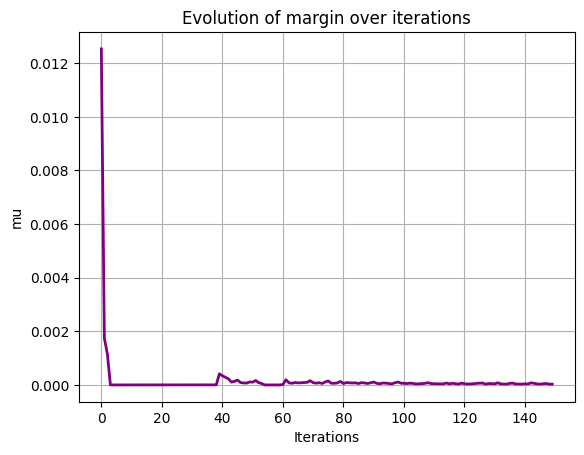

15:10:37 | INFO | machinemoo | Fit runtime: 51.37 seconds


In [12]:
method = 'mola'
w_scalar = MLPScalarization(num_objs=2, 
                            X=X_train, 
                            y=y_train,
                            fair_feat=fair_feature,
                            gradient=False)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = moopt.get_hypervolumes()
results[f"{method}_grad"] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

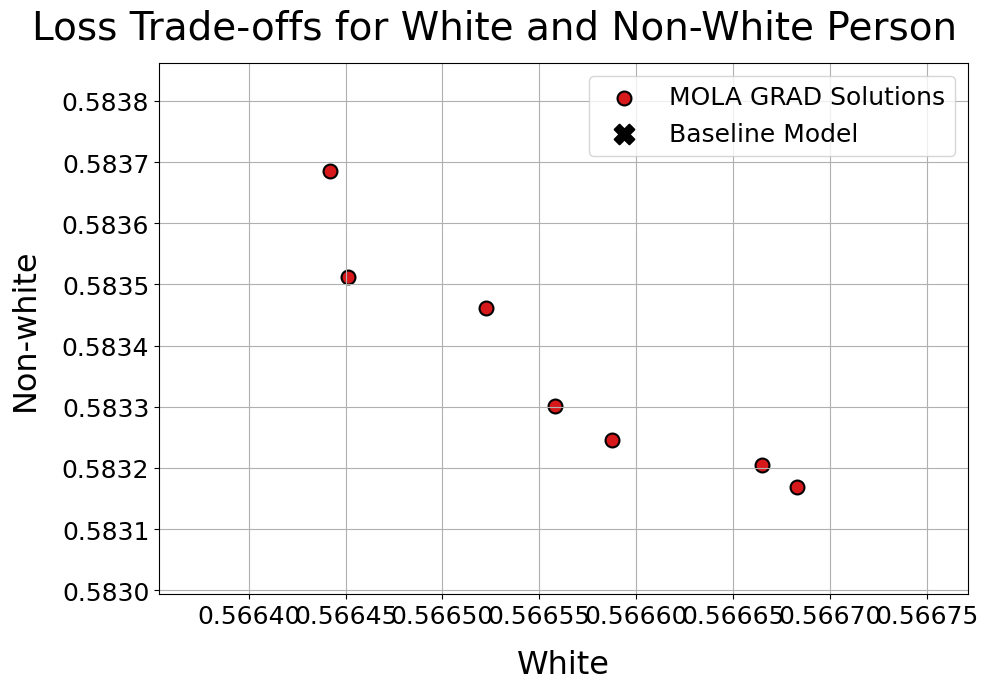

In [13]:
title="Loss Trade-offs for White and Non-White Person"
plot_pareto(methods={'mola_grad': objs},
            labels=("White", "Non-White"), 
            title=title,
            point=equal.objs,
            fontsize=23,
            figsize=(10,7),
            save_path='images/2_objs_mola_grad_mlp.pdf'
            )

## Random Weight

In [14]:
method = 'random_weight'
w_scalar = MLPScalarization(num_objs=2, 
                            X=X_train, 
                            y=y_train,
                            fair_feat=fair_feature,
                            gradient=False)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = compute_hypervolume_progress(objs)
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

15:10:38 | WARNING | machinemoo | Ignored parameters for random_weights: {'nodeTimeLimit', 'targetGap', 'nodeGap'}
15:10:38 | DEBUG | machinemoo | Filtered parameters for random_weights: {'targetSize': 150, 'norm': False}
15:10:38 | DEBUG | machinemoo | Finding 1th individual minima
15:10:38 | DEBUG | machinemoo | Finding 2th individual minima
15:10:38 | DEBUG | machinemoo | 3th solution
15:10:39 | DEBUG | machinemoo | 4th solution
15:10:39 | DEBUG | machinemoo | 5th solution
15:10:39 | DEBUG | machinemoo | 6th solution
15:10:39 | DEBUG | machinemoo | 7th solution
15:10:40 | DEBUG | machinemoo | 8th solution
15:10:40 | DEBUG | machinemoo | 9th solution
15:10:40 | DEBUG | machinemoo | 10th solution
15:10:41 | DEBUG | machinemoo | 11th solution
15:10:41 | DEBUG | machinemoo | 12th solution
15:10:41 | DEBUG | machinemoo | 13th solution
15:10:41 | DEBUG | machinemoo | 14th solution
15:10:42 | DEBUG | machinemoo | 15th solution
15:10:42 | DEBUG | machinemoo | 16th solution
15:10:42 | DEBUG 

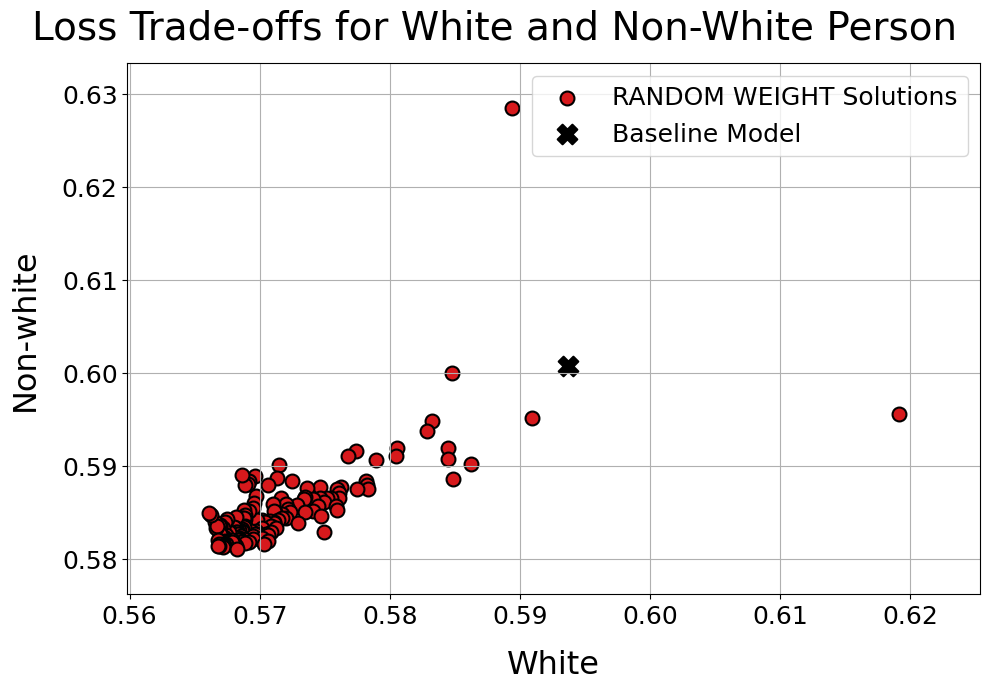

In [18]:
title="Loss Trade-offs for White and Non-White Person"
plot_pareto(methods={'random_weight': objs},
            labels=("White", "Non-White"), 
            title=title,
            point=equal.objs,
            fontsize=23,
            figsize=(10,7),
            save_path='images/2_objs_mola_grad_mlp.pdf'
            )

## A posteriori Decision Making

* Comparison between MOO methods
* Ensemble and Evaluation

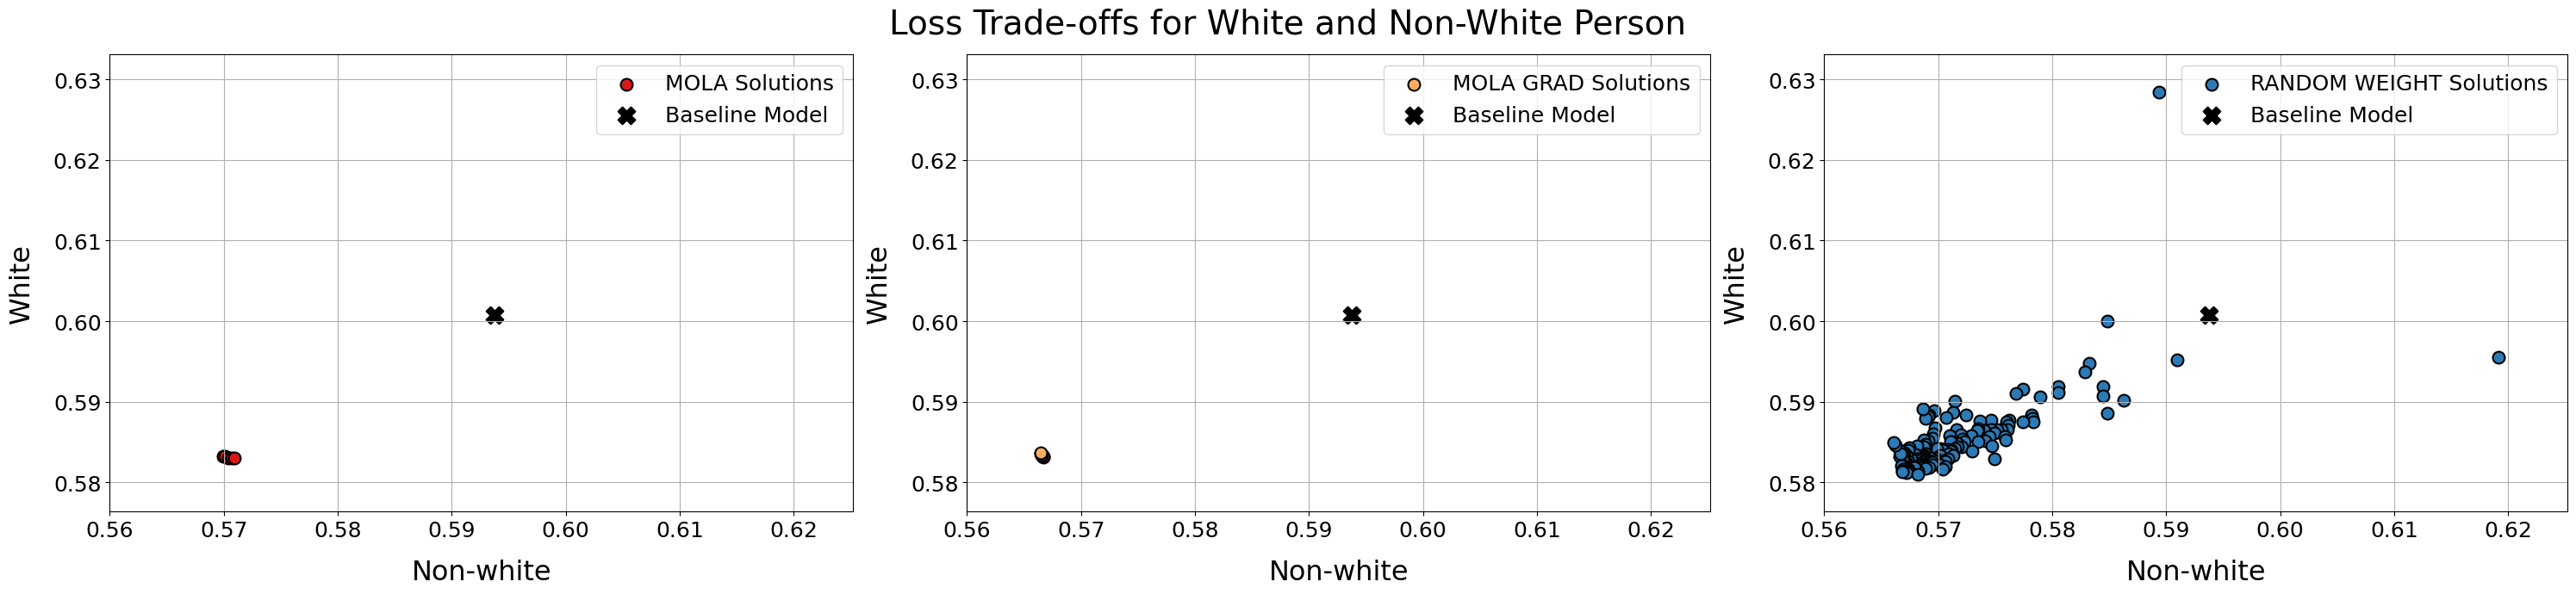

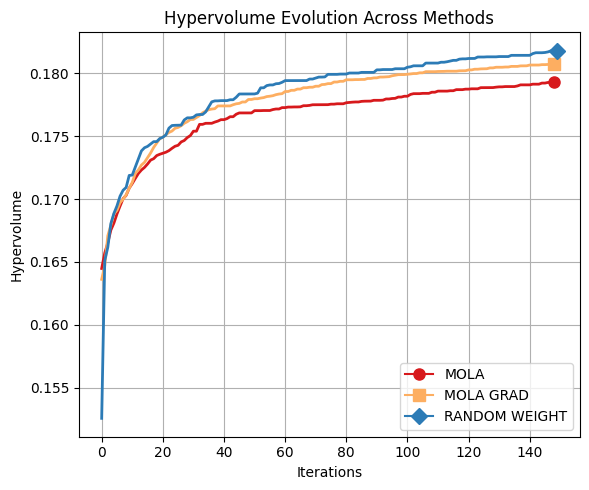

In [15]:
pareto_dict = {
        method: res["objectives"]
        for method, res in results.items()
        if "objectives" in res
    }

hypervolumes_dict = {
        method: res["hypervolume"]
        for method, res in results.items()
        if "hypervolume" in res
    }

axes_label = ["Non-White", "White"]
plot_pareto(methods=pareto_dict,
            labels=axes_label, 
            title=title,
            point=equal.objs,
            fontsize=23,
            figsize=(10,7),
            save_path='images/2_objs_methods_mlp.pdf'
            )

plot_multiple_hypervolumes(methods_hv=hypervolumes_dict)

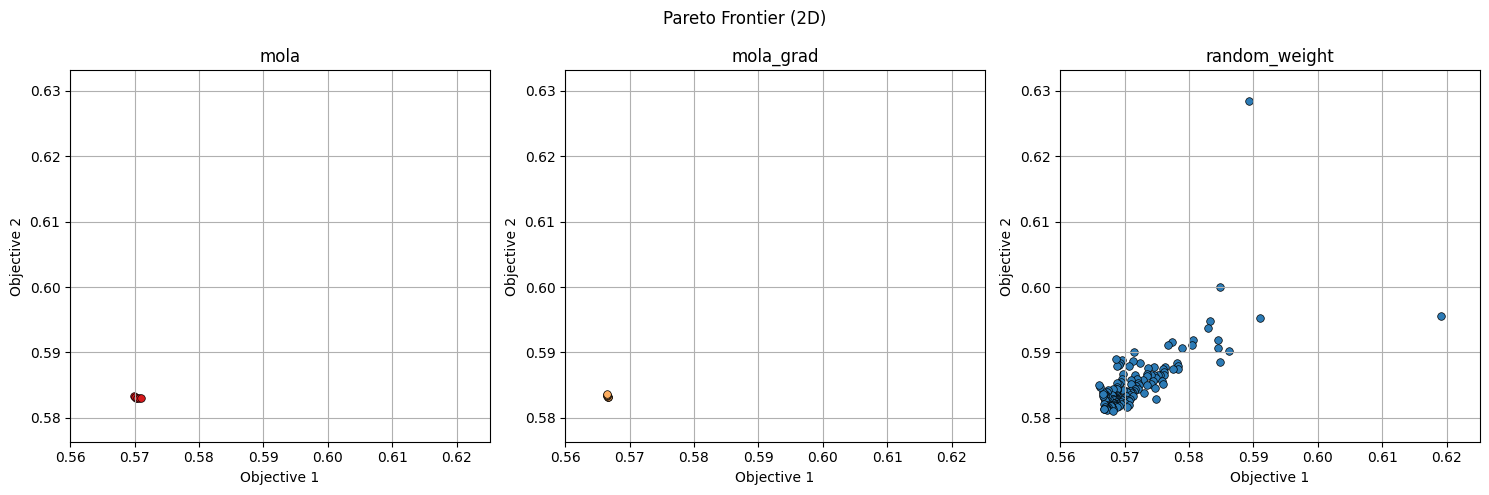

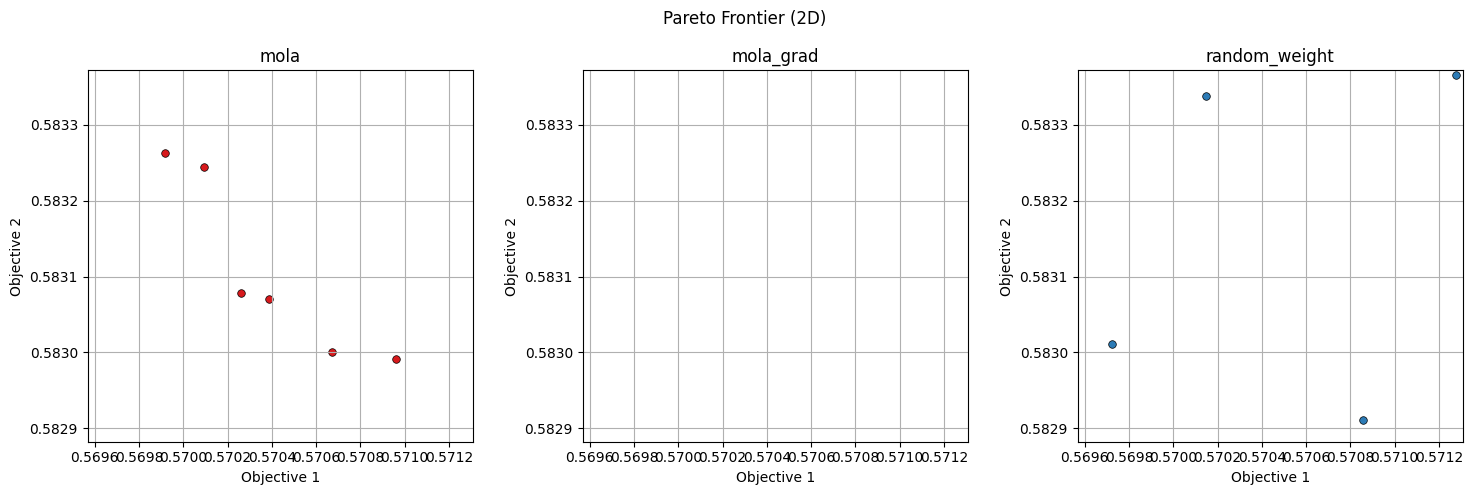

In [16]:
from machinemoo.analysis.visualization import plot_pareto_2d_set_limit
plot_pareto_2d_set_limit(pareto_dict=pareto_dict, axis_mode="global")
plot_pareto_2d_set_limit(pareto_dict=pareto_dict, axis_mode="first")